In [143]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist


# Phase 5: Lifting paths back to macroeconomic variables

### 8.3 Linear lift for interpolated latent paths

In [178]:
# A line in diffusion coordinate space gamma

# mapped to macro space by finding m closes points to line and making lifted weight a linear combination

# Need to split the line into discrete points, break into chunks of length approximately the average distance between points in diffusion space
# for each point find m nearest neighbours - how to do this without computing whole knn graph?


def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def graph_degree_density(Psi, h, delta=None, C=1, qtl=None):
    Dsq = squareform(pdist(Psi)**2)
    Wm = np.exp(-Dsq/h); rho = Wm.sum(1)
    rho = rho / rho.mean()
    if delta is None:
        if qtl is None: 
            delta = np.quantile(rho, 0.01)
        else:
            delta = np.quantile(rho, qtl)
    rho = np.maximum(C*rho, delta); V = -np.log(rho)
    return rho, V, delta


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
# df = df.clip(-3, 3); 
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]
dates = df.index; variables = df.columns
diff = diffusion_map(Z, eps=3, k=3); Psi = diff["Psi"]

Dsq_Psi = squareform(pdist(Psi) ** 2); median_Dsq = np.median(Dsq_Psi[Dsq_Psi > 0])
h = 0.1*median_Dsq; rho, V, DELTA = graph_degree_density(Psi, h=h, qtl=0.02)

D_Z = squareform(pdist(Z)); np.fill_diagonal(D_Z, np.inf)

In [145]:
endpoint_pairs = {"GFC": ("2006-03-01", "2008-10-01"), "COVID": ("2019-07-01", "2020-04-01"), 
                  "Fiscal Tightening": ("2019-04-01", "2022-04-01"), "Recession Trough": ("1977-01-01", "1982-07-01")}

In [146]:
def local_neighbourhood_lifting(Z, Psi, start_idx, end_idx, m=10, n_grid=10, tau=0.2):
    start_point, end_point = Psi[start_idx], Psi[end_idx]
    gamma = np.linspace(start_point, end_point, num=n_grid)
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat, gamma

### Baker et al. style lift $\hat z(s) = \mathbf{H}\gamma (s)$

In [169]:
def lift_operator(Z, Psi):
    Z = Z - Z.mean()
    N = Psi.shape[0]; H = np.linalg.lstsq(Psi, Z, rcond=None)[0].T
    error_norm = np.linalg.norm(Z - Psi@H.T + Z.mean(), axis=1)**2
    RMSE = np.sqrt(np.sum(error_norm)/N)
    return H, RMSE

def baker_lift(Z, Psi, start_idx, end_idx, n_grid=10):
    H, _ = lift_operator(Z, Psi)
    start_point, end_point = Psi[start_idx], Psi[end_idx]

    gamma = np.linspace(start_point, end_point, num=n_grid)
    z_hat = gamma@H.T; z_hat += Z.mean()
    z_hat[0] = Z[start_idx]; z_hat[-1] = Z[end_idx]
    return z_hat, gamma

The Baker lift can't fit an intercept since it is in the form $\hat z(s) = \mathbf{H}\gamma (s)$, so I centre the datapoints and add the mean back after computing the transformation.

### 8.3 Lift validation

In [ ]:
def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN


### Density of points in $\gamma(s)$

In [160]:
def latent_density_at_points(query_points, Psi, h, delta):
    query_points = np.asarray(query_points)

    if query_points.ndim == 1:
        query_points = query_points[None, :]

    Dsq_query = cdist(query_points, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query_floor = np.maximum(rho_query, delta)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

### 8.4 Requred Phase 5 outputs

In [171]:
idx_pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

lifted_paths = {name: {"LNL": None, "baker": None, "lnl_validation": None, "baker_validation": None, "density": None} for name in idx_pairs.keys()}

for event, (start_idx, end_idx) in idx_pairs.items():
    z_lnl, gamma = local_neighbourhood_lifting(Z, Psi, start_idx, end_idx, tau=median_Dsq)
    z_baker, _ = baker_lift(Z, Psi, start_idx, end_idx)
    lifted_paths[event]["LNL"] = z_lnl
    lifted_paths[event]["baker"] = z_baker
    lifted_paths[event]["lnl_validation"] = (lift_validation(z_lnl, Z))
    lifted_paths[event]["baker_validation"] = (lift_validation(z_baker, Z))
    lifted_paths[event]["density"] = (latent_density_at_points(gamma, Psi, h=h, delta=DELTA))


### (c) Lift reconstruction diagnostics.
For the Baker style lift method, I can simply report the RMSE calculated in the function which finds $\mathbf{H}$, for the local neighbour lifting method I will test how good the lifting of each diffusion coordinate is.

In [ ]:
def lnl_error(Z, Psi, m=10,  tau=0.2):
    N = Z.shape[0]; Z_hat = np.zeros_like(Z)
    for i in range(N):
        mask = np.ones(N, dtype=bool); mask[i] = 0
        Z_test = Z[mask]; Psi_test = Psi[mask]
        
        nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi_test)
        distances, indices = nn.kneighbors(Psi[i].reshape(1,-1))
        a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
        points = Z_test[indices, :]; Z_hat[i] = np.sum(a[:, :, None] * points, axis=1)

    obs_error = np.linalg.norm(Z - Z_hat, axis=1)
    RMSE = np.sqrt(np.mean(obs_error**2))
    return Z_hat, RMSE

Zmm = np.sum((Z - Z.mean())**2)
baseline_RMSE = np.sqrt(Zmm/N)
H, baker_RMSE = lift_operator(Z, Psi); Z_hat_baker = Psi @ H.T
Z_hat_lnl, lnl_RMSE = lnl_error(Z, Psi, tau=median_Dsq)

print(f'Baseline RMSE: {baseline_RMSE:.4f}')
print(f'Lifting operator RMSE: {baker_RMSE:.4f}')
print(f'LNL RMSE: {lnl_RMSE:.4f}')

R2_baker = 1 - (np.sum((Z-Z_hat_baker)**2)/Zmm)
R2_lnl = 1 - (np.sum((Z-Z_hat_lnl)**2)/Zmm)

print(f'R2 value for baker: {R2_baker:.4f}')
print(f'R2 value for LNL: {R2_lnl:.4f}')

Baseline RMSE: 1.9388
Lifting operator RMSE: 1.5156
LNL RMSE: 1.5373
-2.573422288892401
R2 value for baker: -2.5734
R2 value for LNL: 0.3713


In [200]:
# Baseline: reconstruct every observation by the variable-wise mean
Z_mean = Z.mean(axis=0)
Zmm = np.sum((Z - Z_mean) ** 2)

N, D = Z.shape

baseline_RMSE = np.sqrt(Zmm / N)

H, baker_RMSE = lift_operator(Z, Psi)
Z_hat_baker = Psi @ H.T + Z_mean

Z_hat_lnl, lnl_RMSE = lnl_error(Z, Psi, tau=median_Dsq)

SSE_baker = np.sum((Z - Z_hat_baker) ** 2)
SSE_lnl = np.sum((Z - Z_hat_lnl) ** 2)

R2_baker = 1 - SSE_baker / Zmm
R2_lnl = 1 - SSE_lnl / Zmm

rel_RMSE_baker = baker_RMSE / baseline_RMSE
rel_RMSE_lnl = lnl_RMSE / baseline_RMSE

baker_RMSE_per_var = baker_RMSE / np.sqrt(D)
lnl_RMSE_per_var = lnl_RMSE / np.sqrt(D)
baseline_RMSE_per_var = baseline_RMSE / np.sqrt(D)

summary = pd.DataFrame({
    "Method": ["Mean baseline", "Baker linear lift", "Local-neighbour lift"],
    "RMSE": [baseline_RMSE, baker_RMSE, lnl_RMSE],
    "RMSE_per_variable": [baseline_RMSE_per_var, baker_RMSE_per_var, lnl_RMSE_per_var],
    "Relative_RMSE": [1.0, rel_RMSE_baker, rel_RMSE_lnl],
    "R2": [0.0, R2_baker, R2_lnl],
})

display(summary)

,Method,RMSE,RMSE_per_variable,Relative_RMSE,R2
0,Mean baseline,1.938805,0.289020,1.000000,0.000000
1,Baker linear lift,1.515567,0.225927,0.781701,0.388939
2,Local-neighbour lift,1.537272,0.229163,0.792896,0.371315


The LNL RMSE is leave-one-out whereas the Baker style RMSE uses in-sample testing.

(d) Plausablilty diagnostics - test the linear path plausability by checking how close to real points

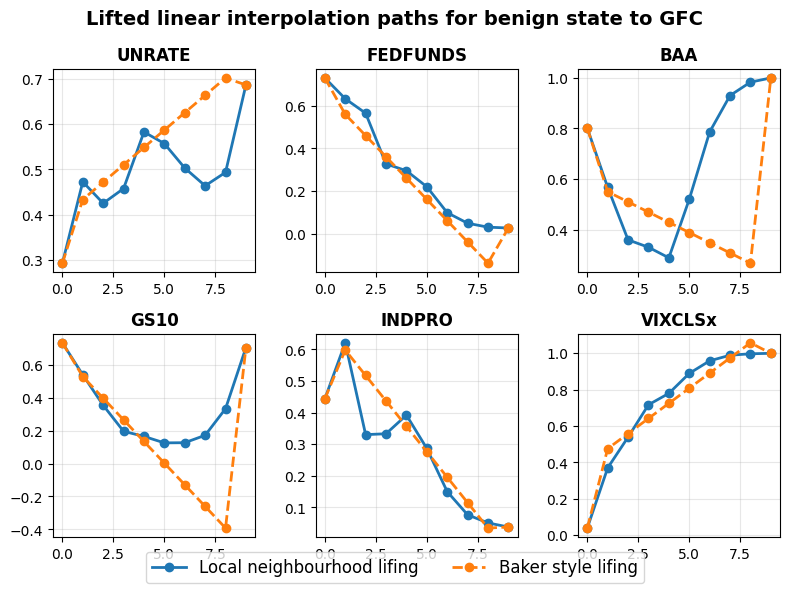

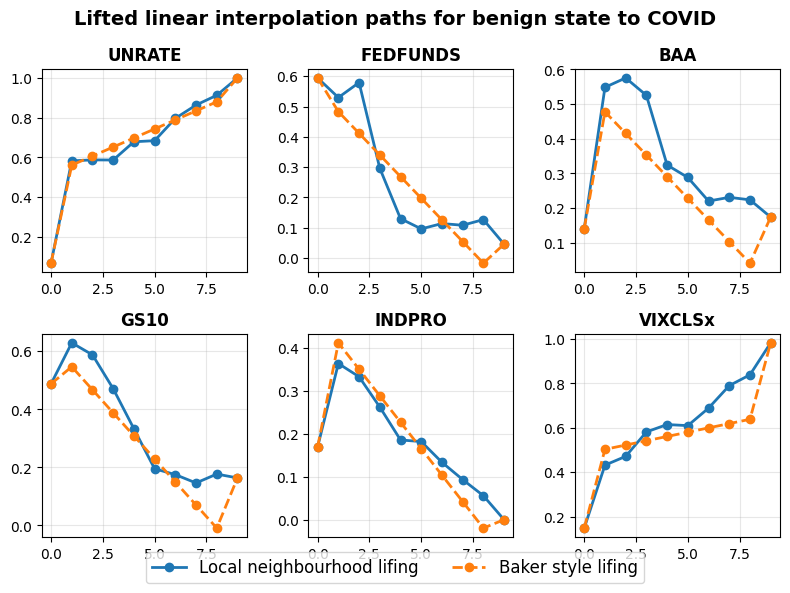

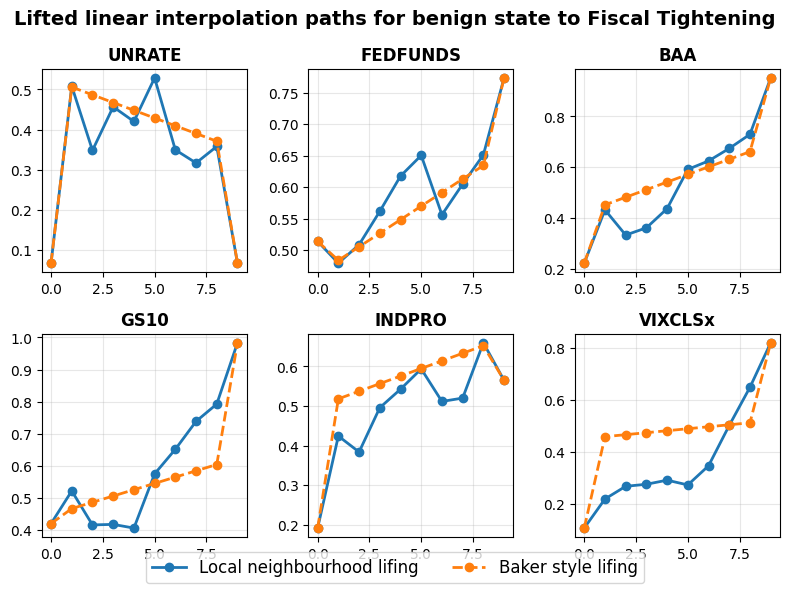

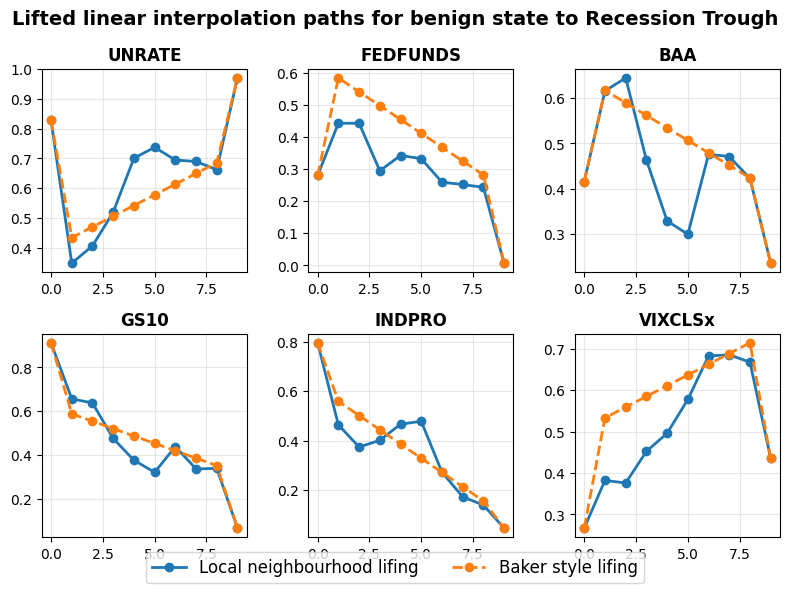

In [ ]:
event = "Recession Trough"

selected_vars = ["UNRATE", "FEDFUNDS", "BAA", "GS10", "INDPRO", "VIXCLSx"]
selected_idxs = [variables.get_loc(col) for col in selected_vars]

for event in lifted_paths.keys():
    local_neighbour_path = lifted_paths[event]["LNL"]
    baker_path = lifted_paths[event]["baker"]

    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes_flat = axes.flatten()

    for i, var in enumerate(selected_idxs):
        ax = axes_flat[i]
        ax.plot(local_neighbour_path[:, var], marker="o", linewidth=2)
        ax.plot(baker_path[:, var], marker="o", linewidth=2, linestyle="--")
        ax.set_title(selected_vars[i], fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

    plt.suptitle(f"Lifted linear interpolation paths for benign state to {event}", fontsize=14, fontweight='bold')
    fig.legend(labels=["Local neighbourhood lifing", "Baker style lifing"], loc="lower center", ncol=2, fontsize=12,bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10, hspace=0.3, wspace=0.3)
    plt.show()

These are in the quantile standardised units